In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict

In [2]:
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win_distance,  jaro_win
from modules.group_dr import add_multi_chart

In [3]:
df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/Data/surveys (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['SURVEY_DATE'])

In [4]:
sample = df.head(2000)

In [5]:
sample.head()

,HASH,CLIENT_ID,SURVEY_WEEK,SURVEY_DATE,ADDRESS,EMAIL,POSITION,DISB_DATE,INDUSTRY,DISBURSED,DR1,DEFAULTED,PTFRAUD
0,ecpb0,178484003,2024-02-05,2024-02-05 09:36:39,Peace church,acquahmary574@gmail.com,Packaging,2024-02-05 09:40:44.000,Food Industry,1,0,0,0
1,NaN,844806159,2024-01-29,2024-01-30 23:10:06,GBC bank,hensy.ai@gmail.com,Owner,2024-01-30 23:29:41.000,Transportation,1,0,0,0
2,ecpb1,832139937,2024-01-22,2024-01-27 17:15:06,ATTA MILLS,arhinm220@gmail.com,DRIVER,2025-02-06 11:16:37.000,Transportation,1,0,1,0
3,ecy1p,279135133,2024-03-04,2024-03-05 21:10:31,old karaga street,NaN,accountant,2024-03-05 21:21:50.000,Healthcare,1,0,0,0
4,ebzze,368413062,2024-03-04,2024-03-06 19:42:23,Abebrese Street,dadzitheodora77@gmail.com,nurse,2024-03-19 08:52:37.000,Healthcare,1,0,0,0


In [6]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   HASH         1720 non-null   object        
 1   CLIENT_ID    2000 non-null   int64         
 2   SURVEY_WEEK  2000 non-null   object        
 3   SURVEY_DATE  2000 non-null   datetime64[ns]
 4   ADDRESS      2000 non-null   object        
 5   EMAIL        1262 non-null   object        
 6   POSITION     1919 non-null   object        
 7   DISB_DATE    2000 non-null   object        
 8   INDUSTRY     1919 non-null   object        
 9   DISBURSED    2000 non-null   int64         
 10  DR1          2000 non-null   int64         
 11  DEFAULTED    2000 non-null   int64         
 12  PTFRAUD      2000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 203.3+ KB


Iterating over multiple similarity threholds

In [7]:
# records = []
# for i in range(2, 7):
#     output = defaultdict(list) 
#     res = jaro_win(df, 15, i, 0.90)
#     res['dup_limit'] = i    
#     output['dup_limit'] = i
#     output['sim_threshold'] = 0.90
#     output['n_surveys'] = res['CLIENT_ID'].count()
#     output['n_disbursed'] = res['DISBURSED'].sum()
#     output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
#     records.append(output)
# address_dup_fraud = res.copy()

# output1 = pd.DataFrame(records)

In [8]:
# output1


In [9]:
records = []
for i in range(2, 6):
    for j in range(8, 16, 2):
        output = defaultdict(list) 
        res = lev_win_distance(df, j, i, 0)
        res['dup_limit'] = i   
        output['dup_limit'] = i
        output['window'] = j
        output['sim_threshold'] =0
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
address_dup_fraud = res.copy()

output2 = pd.DataFrame(records)

In [10]:
output2

,dup_limit,window,sim_threshold,n_surveys,n_disbursed,dr
0,2,8,0,2998,1443,0.279972
1,2,10,0,3711,1792,0.267299
2,2,12,0,4529,2182,0.258478
3,2,14,0,5330,2565,0.249513
4,3,8,0,951,444,0.342342
5,3,10,0,1304,616,0.300325
6,3,12,0,1750,811,0.277435
7,3,14,0,2169,1004,0.264940
8,4,8,0,355,158,0.468354
9,4,10,0,585,268,0.361940


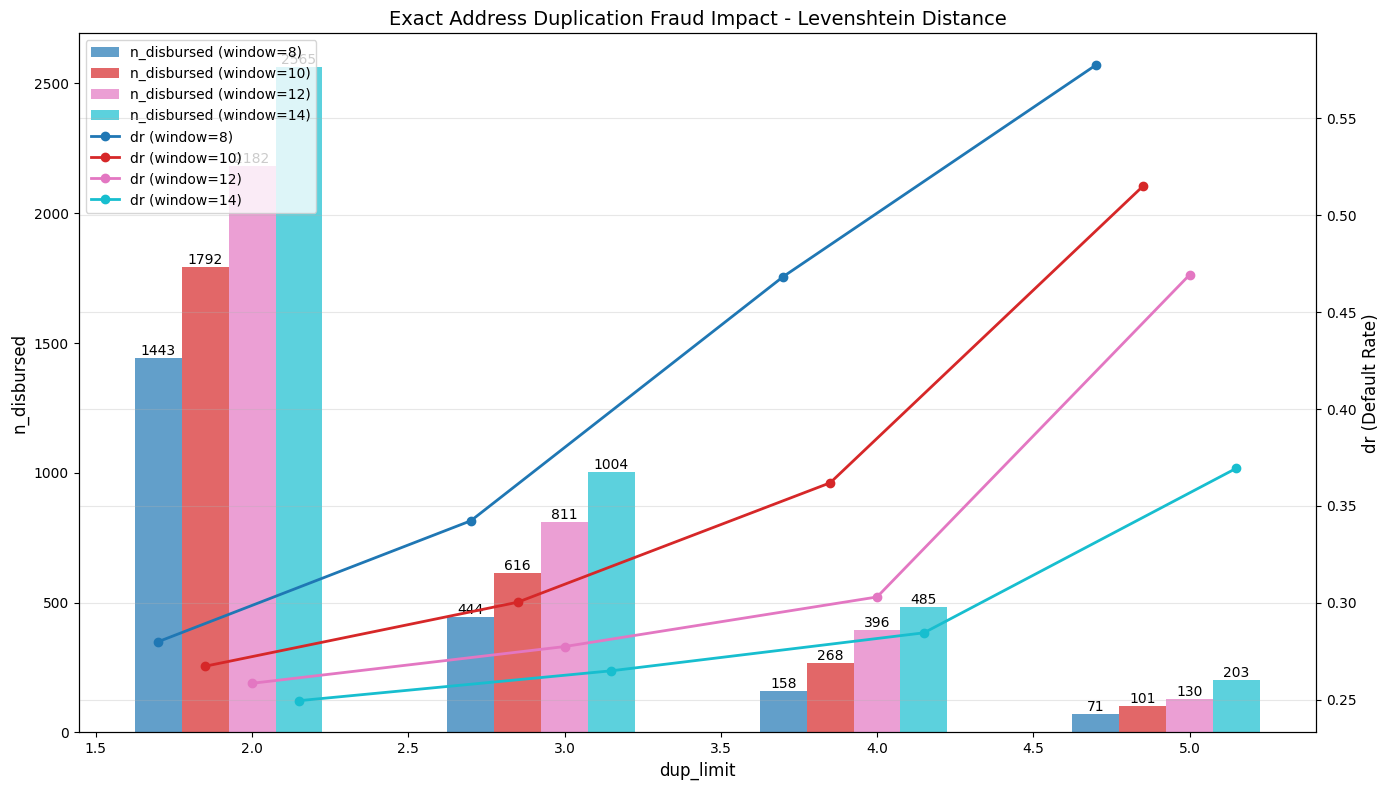

In [11]:
add_multi_chart(output2, 'Exact Address Duplication Fraud Impact - Levenshtein Distance', 'dup_limit', 'window')

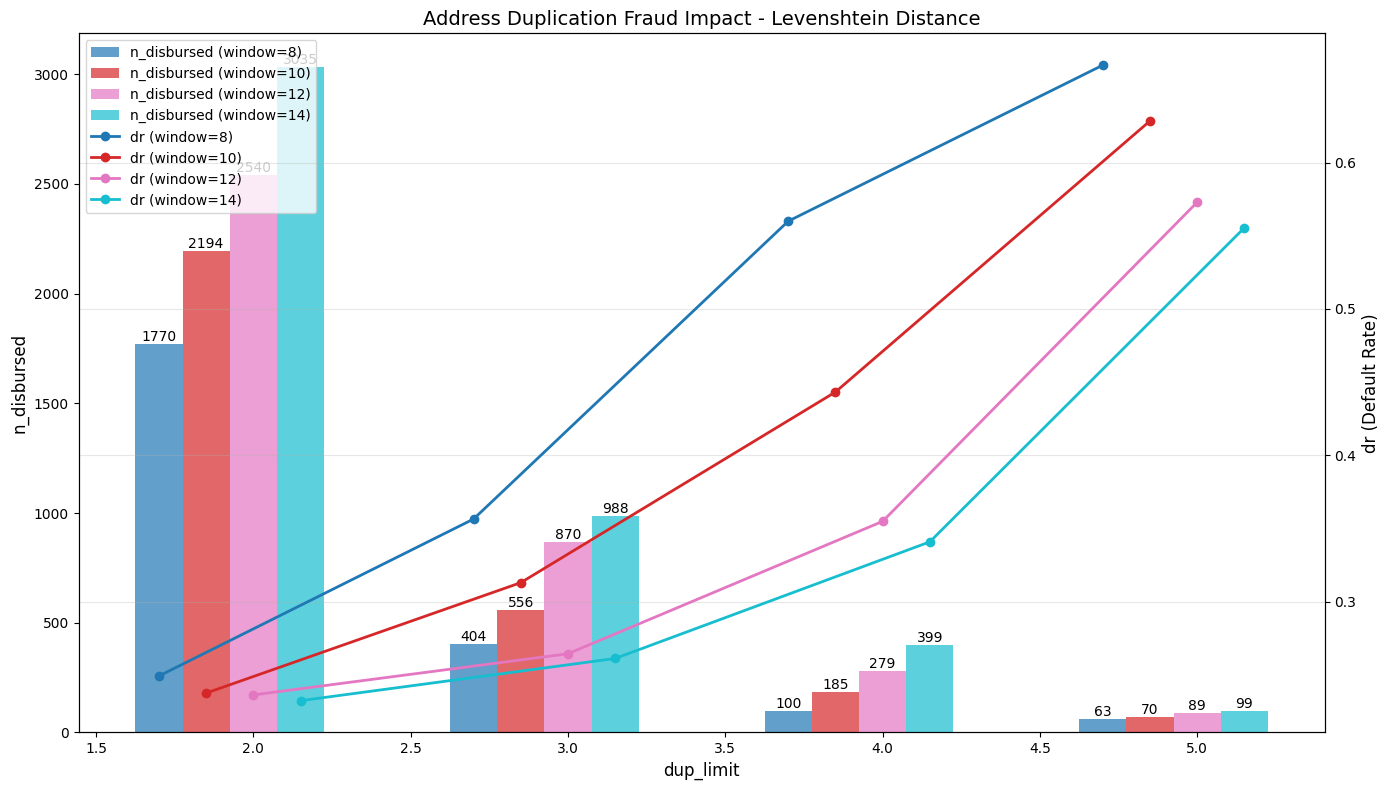

In [29]:
records = []
for i in range(2, 6):
    for j in range(8, 16, 2):
        output = defaultdict(list) 
        res = lev_win_distance(df, j, i, 1)
        res['dup_limit'] = i   
        output['dup_limit'] = i
        output['window'] = j
        output['sim_threshold'] =1
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
address_dup_fraud = res.copy()

output2 = pd.DataFrame(records)
add_multi_chart(output2, 'Address Duplication Fraud Impact - Levenshtein Distance', 'dup_limit', 'window')

In [36]:
ug_data = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud/notebooks/data/UG 2024 Q1 - 2025 Q1.csv')
ug_data['SURVEY_DATE'] = pd.to_datetime(ug_data['SURVEY_DATE'])
ug_data['HASH'] = ug_data['HASH4']
ug_data['DISBURSED'] = ug_data['DISIBURSED']
ug_data.head()

,SURVEY_DATE,HASH4,HASH,PLATFORM,GROUPS,FRAUD_AREA,CLIENT_ID,ADDRESS,AGE,AIRTEL_WALLET,...,EMPLOYMENT,INCOME_VALUE,INDUSTRY,POSITION,POSLEN,REFERENCE1_PHONE_NUMBER,DISIBURSED,LOANAMOUNT,DR1,DISBURSED
0,2024-10-30,s8p1,s8p1,android,CG,0,788394416,02 brian close,33,False,...,Self-employed,"1,000,001 - 2,000,000 UGX",Agriculture,tomato and matooke farmer,25,256705720520,1,45000.0,0,1
1,2025-04-25,s8n5,s8n5,android,CG,0,506074523,katerre road,32,False,...,Employed full-time,"350,001 - 700,000 UGX",Agriculture,Im famer,8,256777954901,1,45000.0,0,1
2,2025-02-24,kxvg,kxvg,ios,CG,0,708611282,rwekubo kakunyu,59,True,...,Employed full-time,"350,001 - 700,000 UGX",Construction,Driver,6,256708870781,1,45000.0,1,1
3,2024-03-20,s8p1,s8p1,android,CG,0,411439493,KIBULI SS STREET,39,False,...,Employed full-time,"Under 350,000 UGX",Public Administration,driver,7,256788857502,1,30000.0,1,1
4,2024-12-19,s8p4,s8p4,android,CG,0,989257206,GATETE TRADING CENTRE,20,False,...,Self-employed,"350,001 - 700,000 UGX",Electricity and Utilities,Electrician,12,256777974469,1,45000.0,1,1


In [37]:
ug_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16329 entries, 0 to 16328
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   SURVEY_DATE              16329 non-null  datetime64[ns]
 1   HASH4                    16283 non-null  object        
 2   HASH                     16283 non-null  object        
 3   PLATFORM                 16329 non-null  object        
 4   GROUPS                   16329 non-null  object        
 5   FRAUD_AREA               16329 non-null  int64         
 6   CLIENT_ID                16329 non-null  int64         
 7   ADDRESS                  16321 non-null  object        
 8   AGE                      16329 non-null  int64         
 9   AIRTEL_WALLET            16329 non-null  bool          
 10  MTN_WALLET               16329 non-null  bool          
 11  BANK_ACCOUNT             16329 non-null  bool          
 12  HAS_ALTPHONE             16329 n

In [38]:
ug_df = ug_data[['SURVEY_DATE', 'HASH', 'ADDRESS', 'DISBURSED', 'DR1', 'CLIENT_ID', 'POSITION', 'INDUSTRY']]

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_37467/4065954692.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_37467/4065954692.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_37467/4065954692.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_37467/4065954692.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


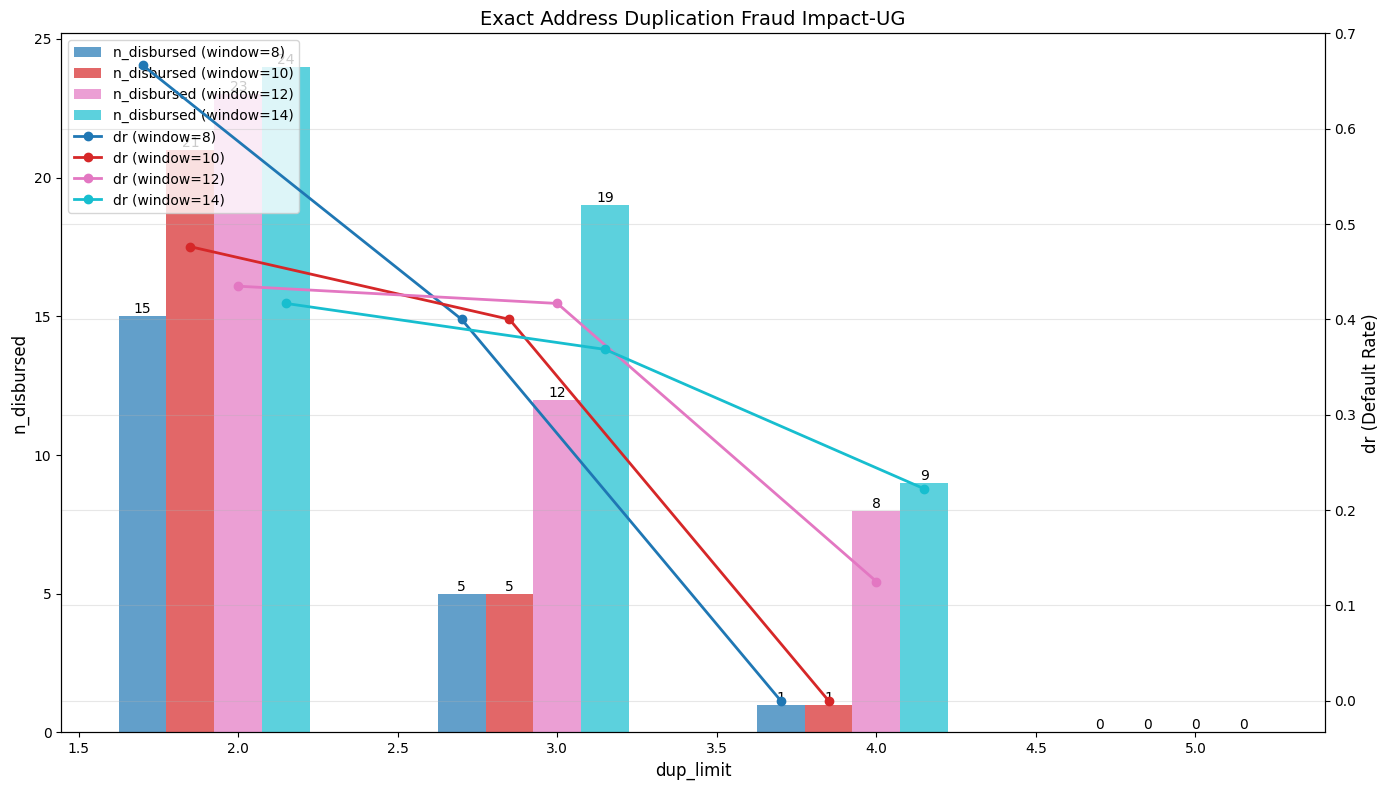

In [40]:
records = []
for i in range(2, 6):
    for j in range(8, 16, 2):
        output = defaultdict(list) 
        res = lev_win_distance(ug_df, j, i, 0)
        res['dup_limit'] = i   
        output['dup_limit'] = i
        output['window'] = j
        output['sim_threshold'] =0
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
address_dup_fraud = res.copy()

output2 = pd.DataFrame(records)
add_multi_chart(output2, 'Exact Address Duplication Fraud Impact-UG', 'dup_limit', 'window')

In [16]:
res

,TIME,HASH4,HASH5,PLATFORM,GROUPS,FRAUD_AREA,CLIENT_ID,ADDRESS,AGE,AIRTEL_WALLET,...,HASH,DISBURSED,FRAUD_TYPE,SIMILAR_PRIOR_ADDRESS,SIMILAR_ADDRESSES_COUNT,ADDRESS_DISTANCE,IS_WHITELISTED,DEFAULT_RATE,DAYS_SINCE_LAST,dup_limit


In [ ]:
address_dup_fraud.to_csv('address_dup_fraud_levenshtein.csv')

In [ ]:
add_multi_chart(output2, 'Address Duplication Fraud Impact-Levenshtein', 'dup_limit', 'sim_threshold')

In [20]:
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = jaro_win(df, 15, i, 1)
    res['dup_limit'] = i    
    output['dup_limit'] = i
    output['sim_threshold'] =1
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)
address_dup_fraud = res.copy()

output3 = pd.DataFrame(records)

In [21]:
output3

,dup_limit,sim_threshold,n_surveys,n_disbursed,dr
0,2,1,284,137,0.510949
1,3,1,131,60,0.633333
2,4,1,72,30,0.733333
3,5,1,43,16,0.875000
4,6,1,26,10,0.900000


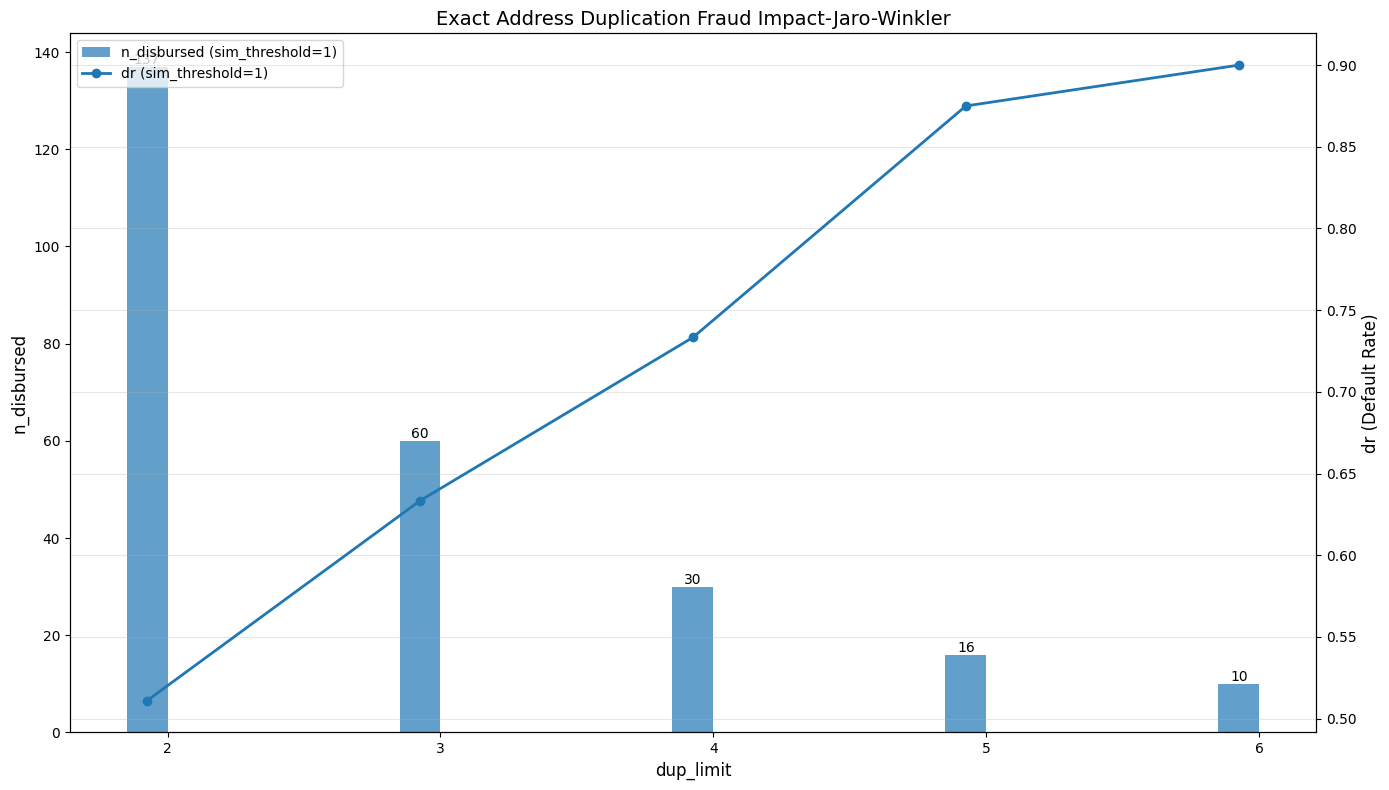

In [22]:
add_multi_chart(output3, 'Exact Address Duplication Fraud Impact-Jaro-Winkler', 'dup_limit', 'sim_threshold')

MultiColumn Duplications Iterations

In [8]:
# records = []
# for i in range(2, 6):
#     output = defaultdict(list) 
#     res = lev_win(df, 15, i, 3)
#     output['dup_limit'] = i
#     output['n_surveys'] = res['CLIENT_ID'].count()
#     output['n_disbursed'] = res['DISBURSED'].sum()
#     output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
#     records.append(output)



In [24]:
from modules.distance_finder import jaro_win_multi

In [26]:
#iterating over range for position similarity
records = []
for i in range(2, 6):
   
    output = defaultdict(list) 
    res = jaro_win_multi(df, 15, 0.85, 0.85, i)
    res['dup_limit'] = i
    # res['pos_sim'] = j
    output['dup_limit'] = i
    output['pos_sim'] = 0.85
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

In [27]:
output5 = pd.DataFrame(records)
output5

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,0.85,115,75,0.826667
1,3,0.85,77,48,0.875000
2,4,0.85,50,28,1.000000
3,5,0.85,34,18,1.000000


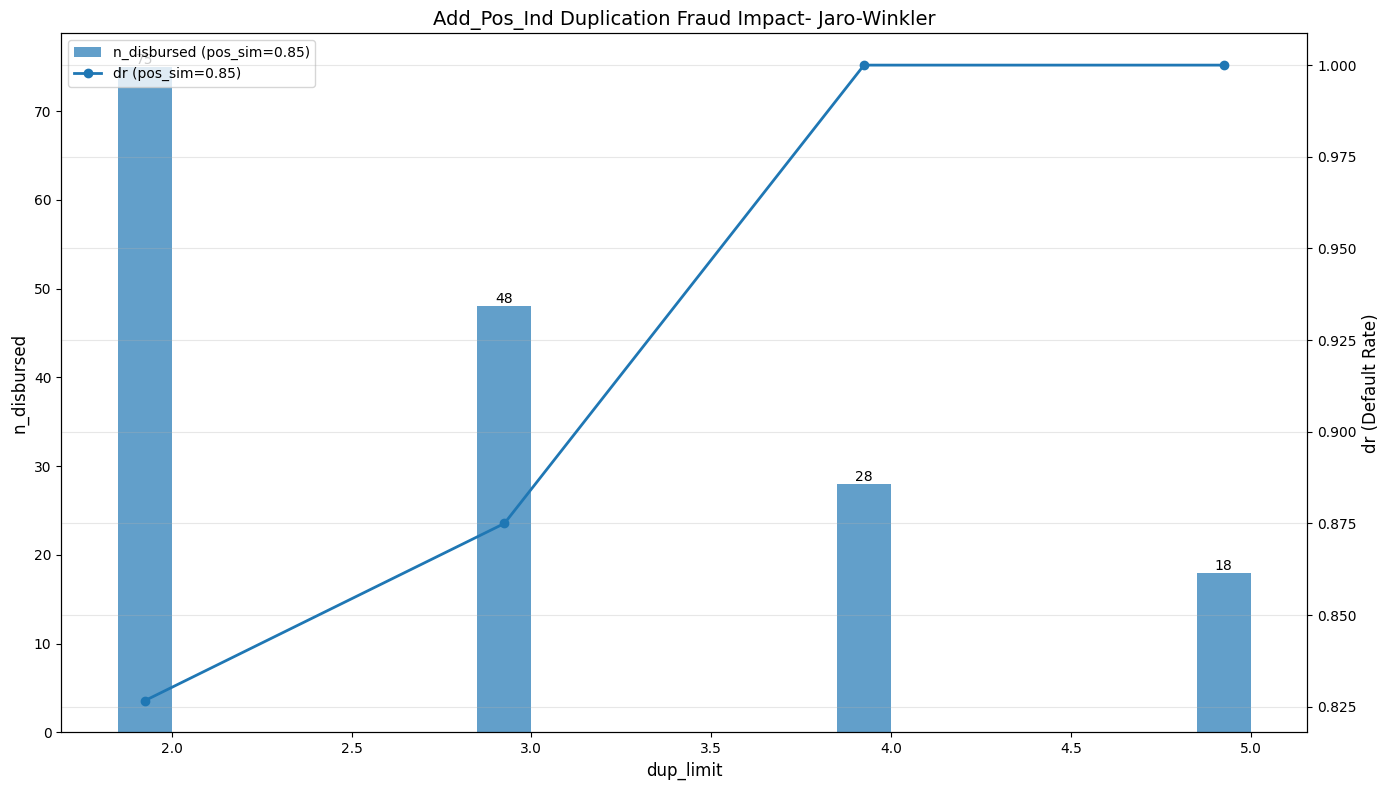

In [28]:
add_multi_chart(output5, 'Add_Pos_Ind Duplication Fraud Impact- Jaro-Winkler', 'dup_limit', 'pos_sim')